In [1]:
import networkx as nx               # for creating, manipulating, and analyzing graphs
import numpy as np                  # for numerical computations and handling arrays or matrices
import matplotlib.pyplot as plt     # for plotting graphs and visualizing results
import pandas as pd                 # for creating and manipulating DataFrames
import time                         # For measuring execution time or adding delays
from pulp import LpProblem, LpVariable, LpMinimize, lpSum, LpStatus, value # for solving linear programs

In [2]:
def read_graphs(nodes, edges):
    """
    Parameters : 
    nodes : int
        Number of nodes in each graph (used for naming files).
    edges : numpy array
        Sequence of edge counts.
        
    Returns :
    graphs_list : list
        A list of NetworkX graphs read from the files.
    """
    graphs_list = []
    n = nodes
    for m in edges:
        filename = f"n={n}_m={m}.txt"
        G = nx.read_edgelist(filename)
        graphs_list.append(G)
    return graphs_list

In [3]:
def lp_vertex_cover(G):
    # Create LP problem instance
    prob = LpProblem("VertexCover", LpMinimize)

    # Create variables: x_v for each vertex v in G
    x = {v: LpVariable(f"x_{v}", lowBound=0, upBound=1) for v in G.nodes()}

    # Objective: minimize sum of x_v
    prob += lpSum(x[v] for v in G.nodes())

    # Constraints: for each edge, at least one endpoint must be in the cover
    for u, v in G.edges():
        prob += x[u] + x[v] >= 1

    # Solve the LP
    prob.solve()

    # Extract fractional solution
    fractional_solution = {v: x[v].varValue for v in G.nodes()}
    
    # Rounding: include vertices with x_v >= 0.5 in the cover
    lp_cover = {v for v, val in fractional_solution.items() if val >= 0.5}

    return lp_cover, fractional_solution


In [4]:
def generate_vertex_covers(n):
    results = []    
    n = int(n)
    max_edge = (n*(n-1))/2 + 1
    m = np.arange(n, max_edge, 10).astype(int)
    graphs = read_graphs(n, m)
    
    for i, graph in enumerate(graphs, start=1): 
        start_time = time.perf_counter()
        vc, frac_sol = lp_vertex_cover(graph)
        print(frac_sol)
        end_time = time.perf_counter()

        node_colors = ['red' if node in vc else 'green' for node in graph.nodes()]
        
        plt.figure(figsize=(6, 6))
        pos = nx.circular_layout(graph)
        nx.draw(graph, pos, with_labels=True, node_color=node_colors, edge_color="blue")

        # Add graph info (n, m, cover size, runtime) as text
        # used plt.text from chatgpt to ensure saving values of n,m and size of vertex cover an the time taken
        plt.text(0.01, 0.02,
                 f"n={n}, m={m[i-1]}, Vertex Cover Size={len(vc)}, time (in seconds)={(end_time - start_time):.6f}",
                 transform=plt.gca().transAxes, fontsize=10, color="black",
                 bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))
    
        # Save visualization
        plt.savefig(f"lp_round_vc_n={n}_m={m[i-1]}.png")
            
        # Store results
        results.append({
            "n": 10,
            "m": m[i-1],
            "vertex_cover_size": len(vc),
            "time_(in seconds)": end_time - start_time
        })
    return results

{'0': 1.0, '7': 0.0, '3': 0.0, '1': 1.0, '2': 0.0, '8': 0.0, '6': 1.0, '9': 1.0, '4': 0.0, '5': 1.0}
{'0': 0.5, '7': 0.5, '3': 0.5, '4': 0.5, '9': 0.5, '1': 0.5, '2': 0.5, '8': 0.5, '6': 0.5, '5': 0.5}
{'0': 0.5, '7': 0.5, '3': 0.5, '4': 0.5, '9': 0.5, '2': 0.5, '8': 0.5, '1': 0.5, '5': 0.5, '6': 0.5}
{'0': 0.5, '7': 0.5, '3': 0.5, '4': 0.5, '9': 0.5, '2': 0.5, '8': 0.5, '6': 0.5, '1': 0.5, '5': 0.5}


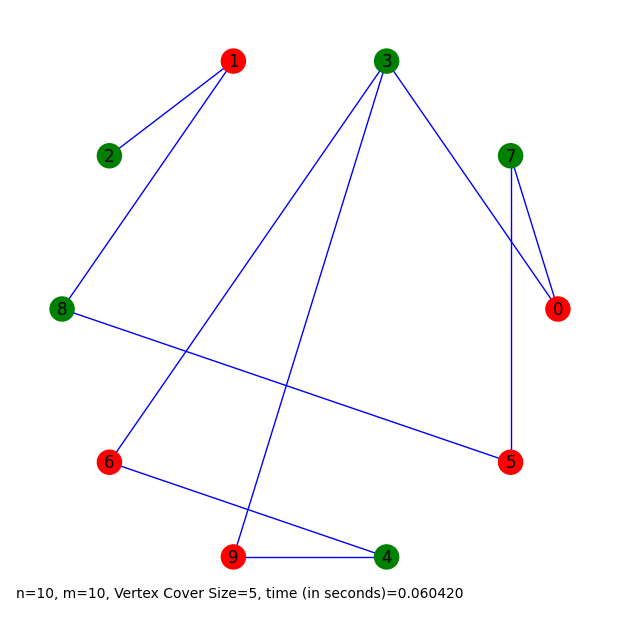

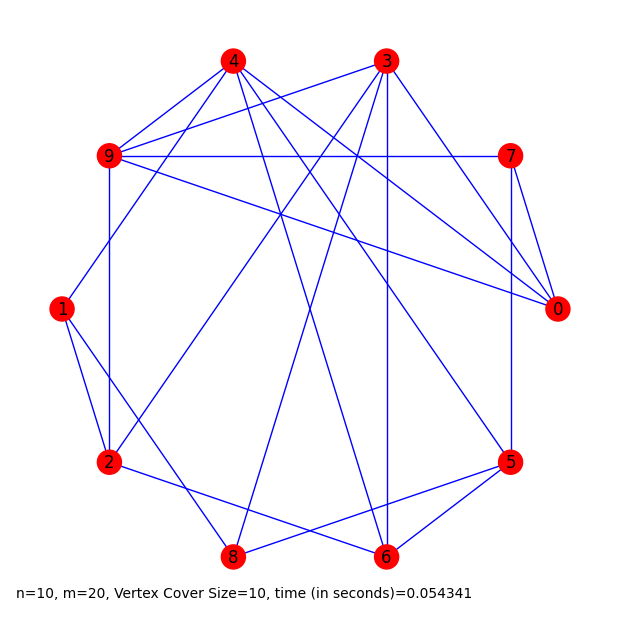

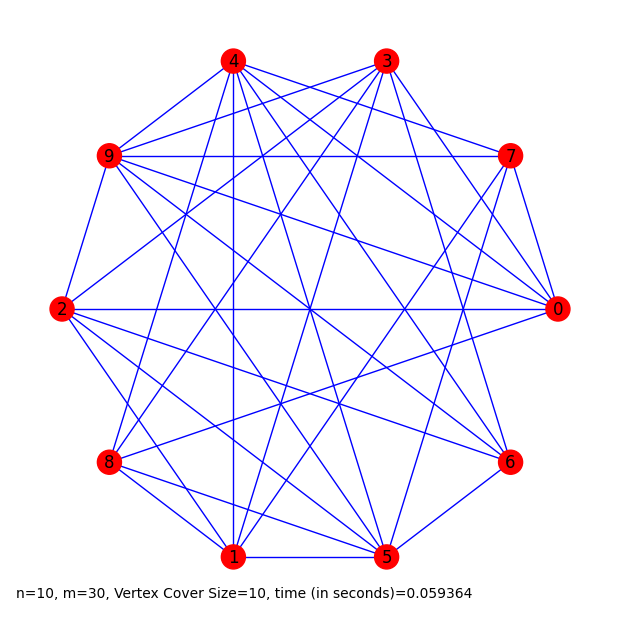

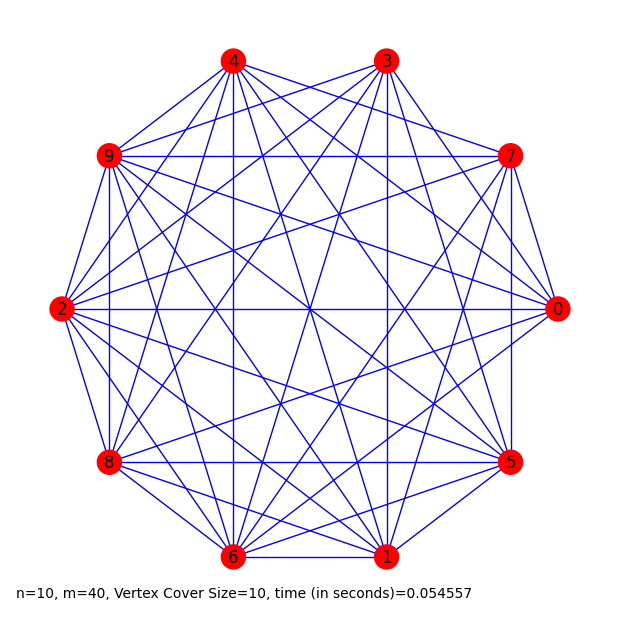

In [5]:
vc_10 = generate_vertex_covers(10)

{'0': 0.5, '14': 0.5, '6': 0.5, '9': 0.5, '1': 0.0, '7': 1.0, '2': 0.5, '5': 0.5, '3': 0.5, '17': 0.5, '4': 0.5, '19': 0.5, '12': 0.5, '18': 0.0, '8': 0.5, '13': 0.5, '10': 0.5, '11': 1.0, '16': 0.0, '15': 0.0}
{'0': 0.5, '14': 0.5, '6': 0.5, '9': 0.5, '19': 0.5, '1': 0.5, '7': 0.5, '5': 0.5, '2': 0.5, '8': 0.5, '10': 0.5, '3': 0.5, '17': 0.5, '4': 0.5, '12': 0.5, '18': 0.5, '13': 0.5, '11': 0.5, '15': 0.5, '16': 0.5}
{'0': 0.5, '14': 0.5, '6': 0.5, '9': 0.5, '19': 0.5, '8': 0.5, '17': 0.5, '1': 0.5, '7': 0.5, '5': 0.5, '2': 0.5, '10': 0.5, '3': 0.5, '4': 0.5, '12': 0.5, '18': 0.5, '13': 0.5, '16': 0.5, '11': 0.5, '15': 0.5}
{'0': 0.5, '14': 0.5, '6': 0.5, '9': 0.5, '19': 0.5, '8': 0.5, '17': 0.5, '1': 0.5, '7': 0.5, '5': 0.5, '2': 0.5, '10': 0.5, '13': 0.5, '4': 0.5, '3': 0.5, '11': 0.5, '12': 0.5, '18': 0.5, '16': 0.5, '15': 0.5}
{'0': 0.5, '14': 0.5, '6': 0.5, '9': 0.5, '19': 0.5, '8': 0.5, '17': 0.5, '1': 0.5, '7': 0.5, '5': 0.5, '13': 0.5, '2': 0.5, '10': 0.5, '4': 0.5, '3': 0.5, 

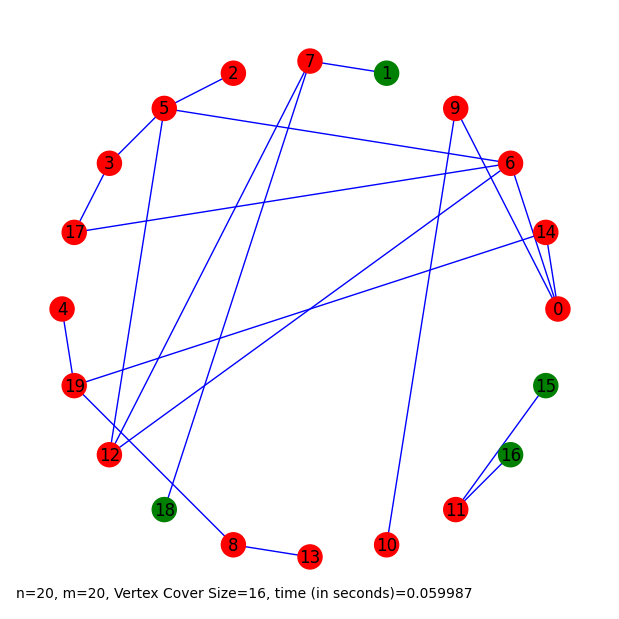

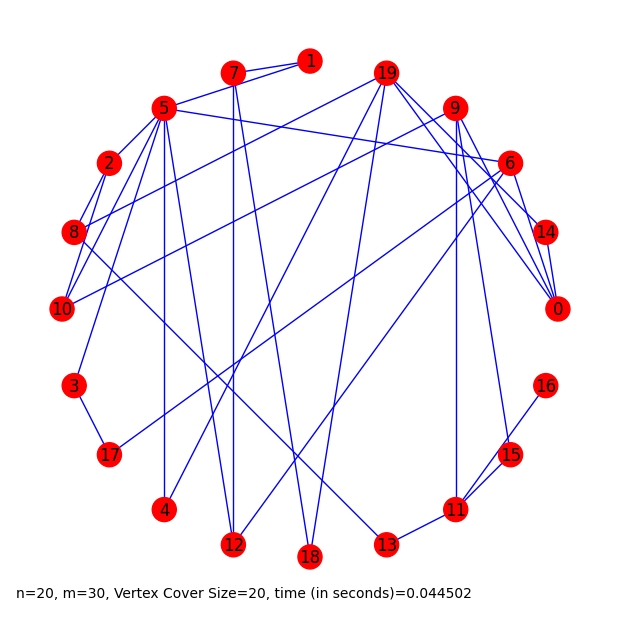

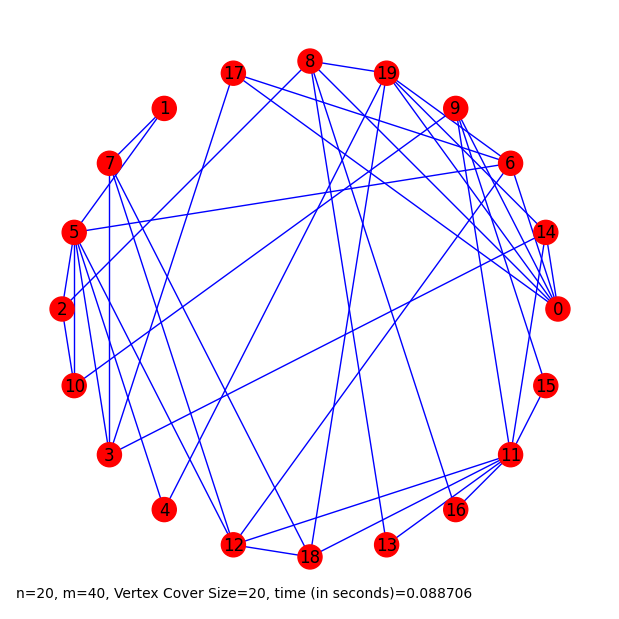

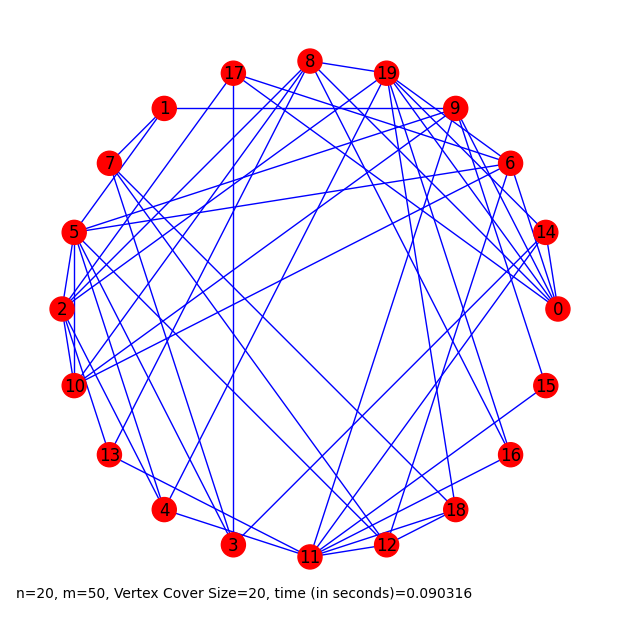

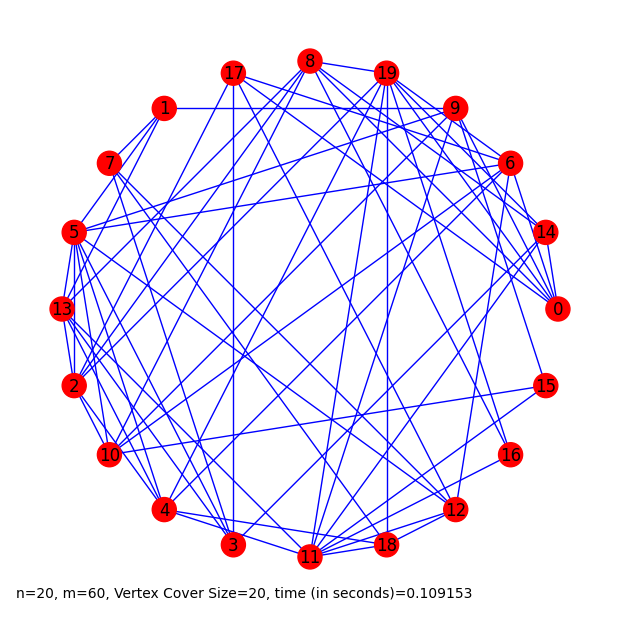

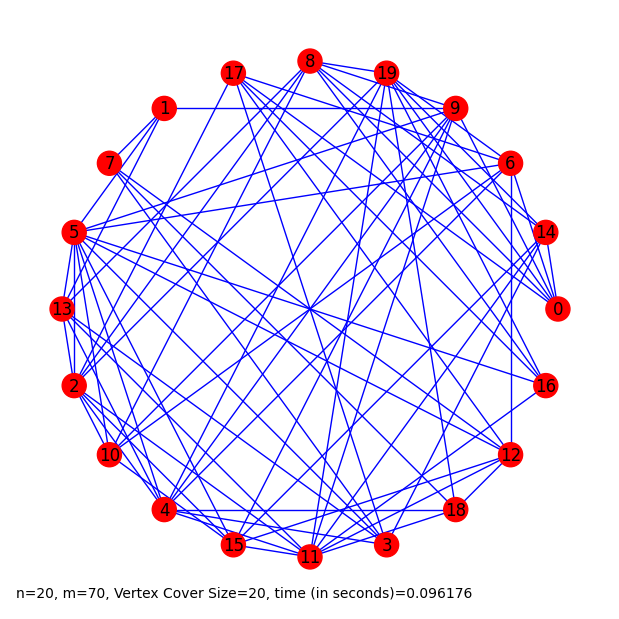

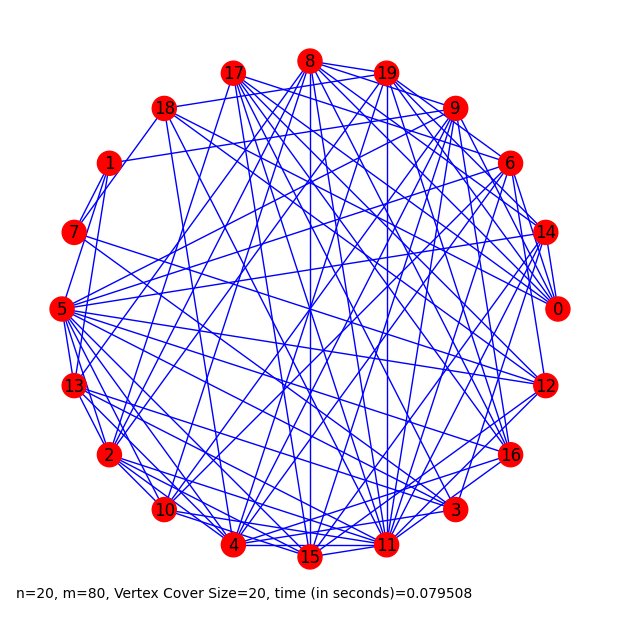

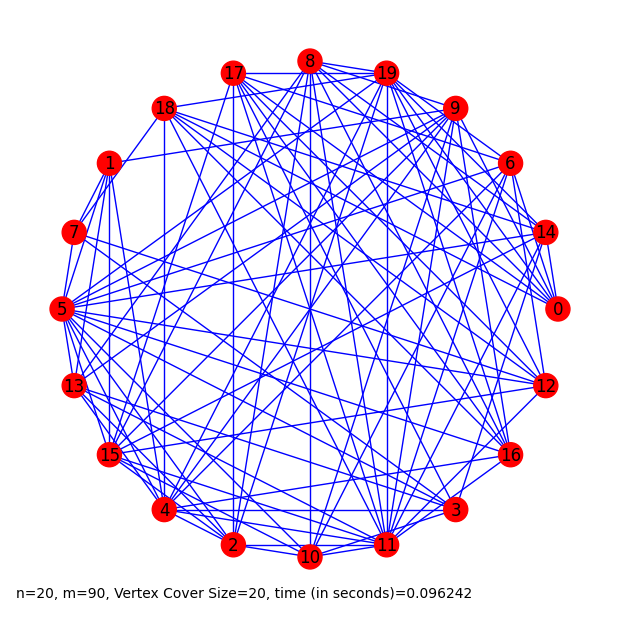

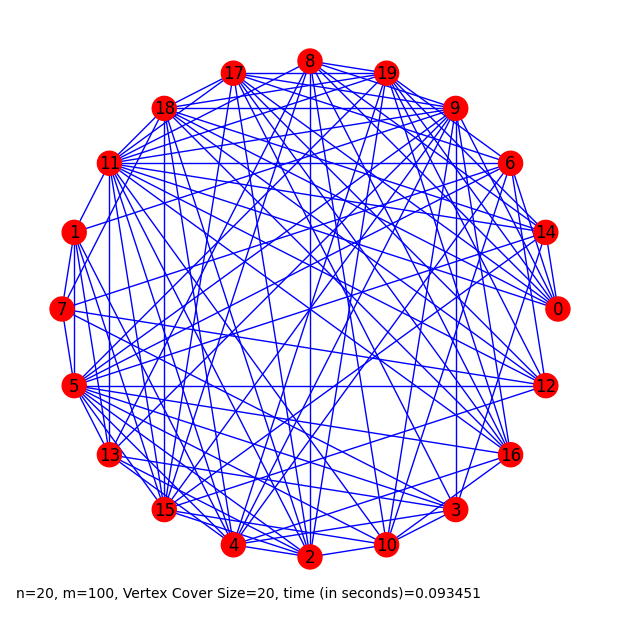

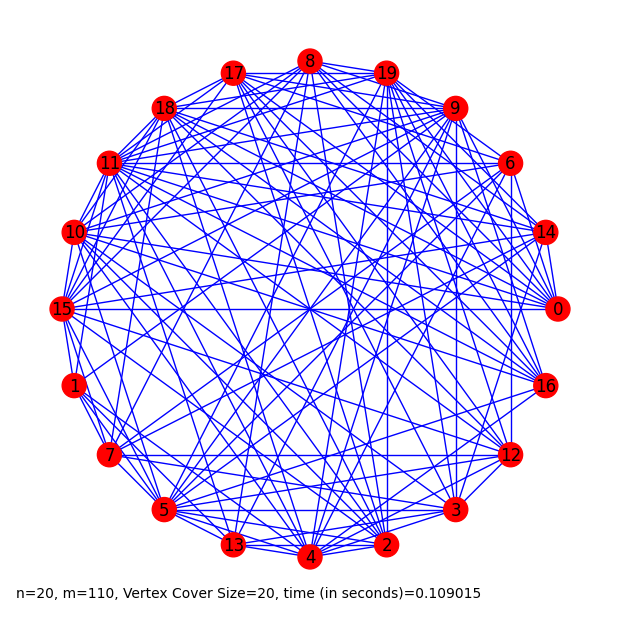

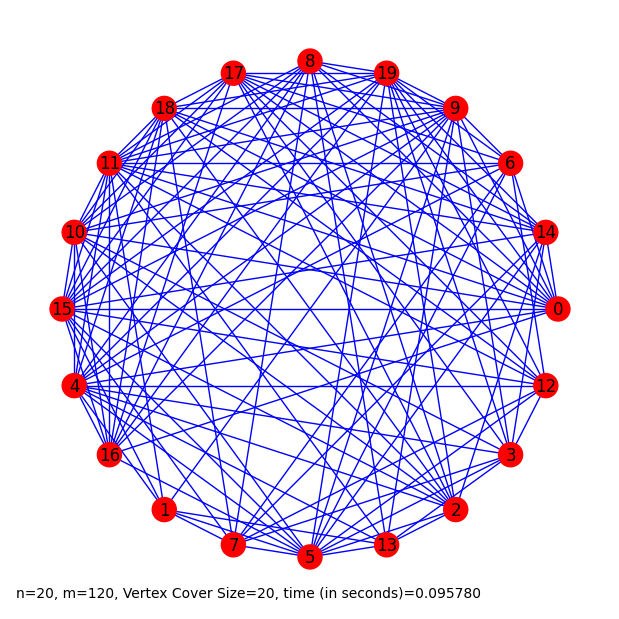

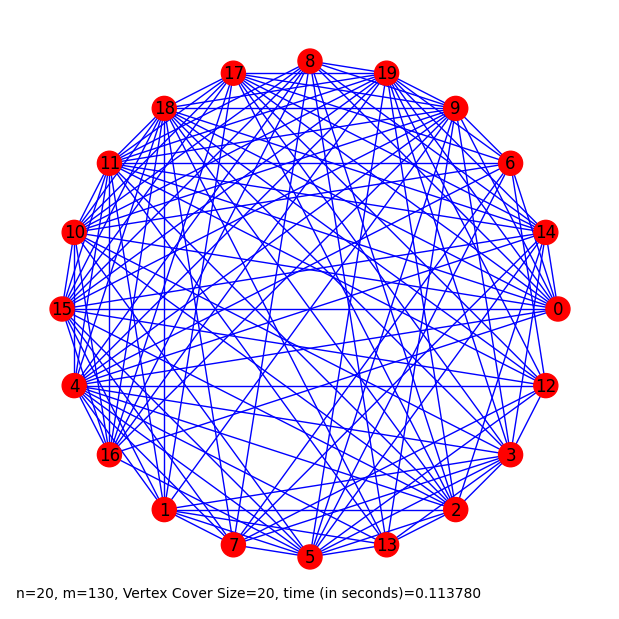

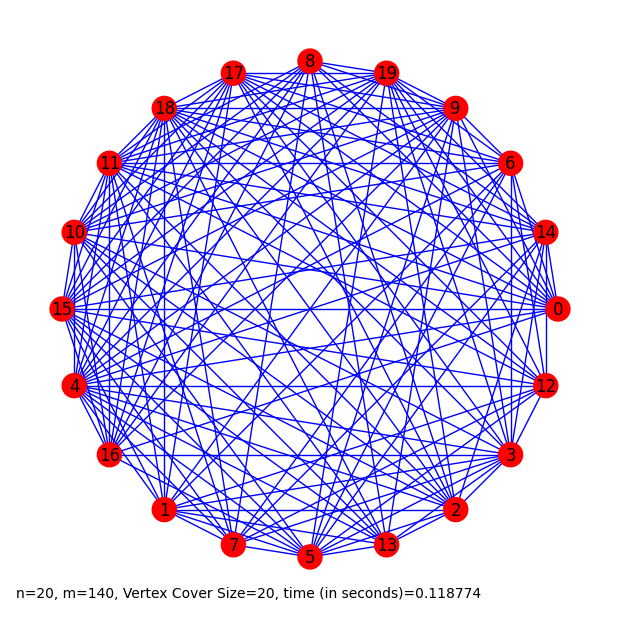

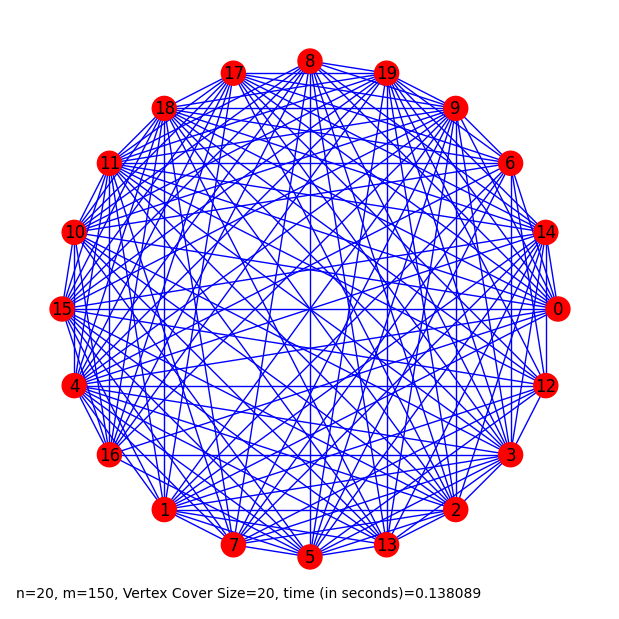

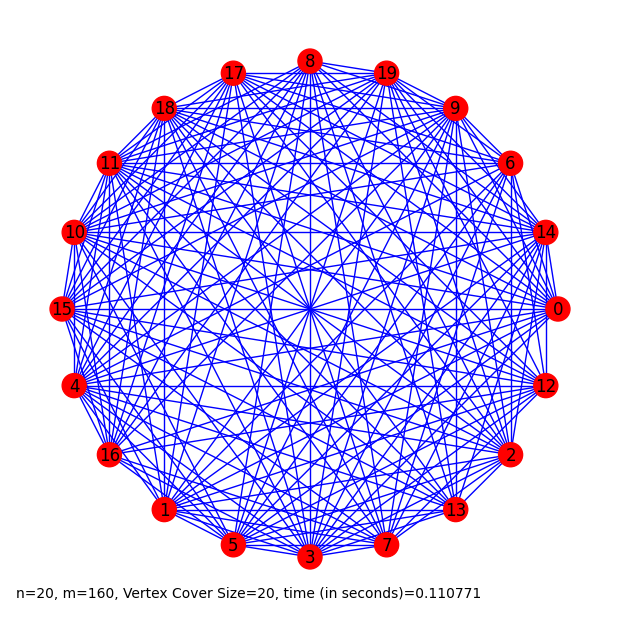

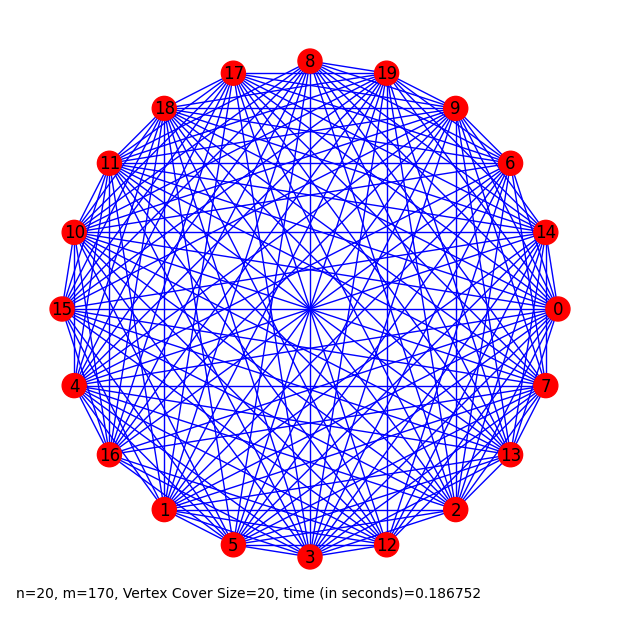

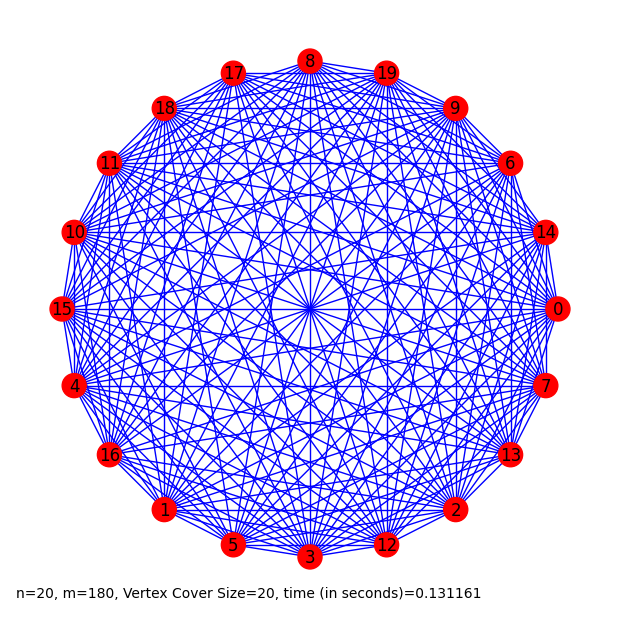

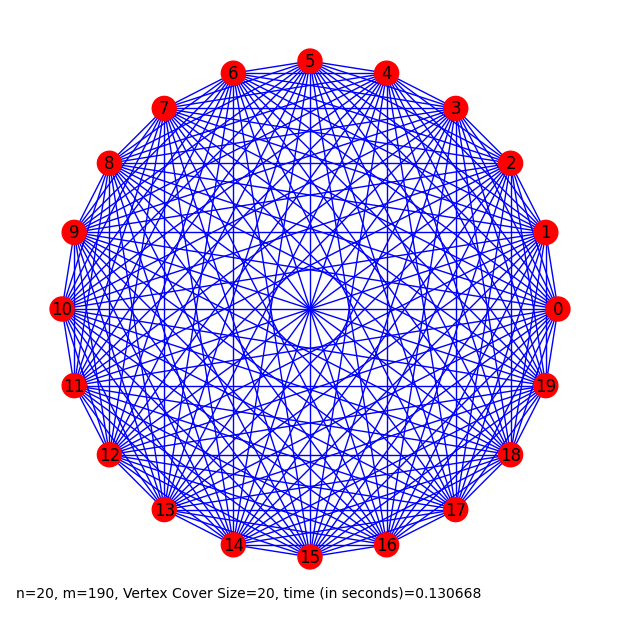

In [6]:
vc_20 = generate_vertex_covers(20)

## comparision of results 

In [8]:
df_lp_10 = pd.DataFrame(vc_10)
df_lp_10

,n,m,vertex_cover_size,time_(in seconds)
0,10,10,5,0.060420
1,10,20,10,0.054341
2,10,30,10,0.059364
3,10,40,10,0.054557


In [9]:
df_10 = pd.read_csv("vertex_cover_results_n_10.csv")
df_10

,n,m,greedy_vertex_cover_size,time (in seconds),opt_vertex_cover_size,opt_vertex_cover_time (in seconds),approximation_factor
0,10,10,8,0.000047,5,0.000969,1.600000
1,10,20,10,0.000098,6,0.002573,1.666667
2,10,30,8,0.000057,7,0.004884,1.142857
3,10,40,10,0.000132,8,0.005507,1.250000


In [10]:
# Add LP (Linear Programming) vertex cover results to df_10
df_10['lp_vertex_cover_size'] = df_lp_10['vertex_cover_size']
df_10['lp_vertex_cover_size_time_(in seconds)'] = df_lp_10['time_(in seconds)']
# Compute approximation ratio between LP and greedy vertex cover sizes
df_10['approximation_lp/greedy'] = df_10['lp_vertex_cover_size'] / df_10['greedy_vertex_cover_size']
# Save results to CSV file
file_path = 'lp_greedy_vc_n_10_comparision.csv'
df_10.to_csv(file_path, index=False)
# Display the final DataFrame
df_10

,n,m,greedy_vertex_cover_size,time (in seconds),opt_vertex_cover_size,opt_vertex_cover_time (in seconds),approximation_factor,lp_vertex_cover_size,lp_vertex_cover_size_time_(in seconds),approximation_lp/greedy
0,10,10,8,0.000047,5,0.000969,1.600000,5,0.060420,0.625
1,10,20,10,0.000098,6,0.002573,1.666667,10,0.054341,1.000
2,10,30,8,0.000057,7,0.004884,1.142857,10,0.059364,1.250
3,10,40,10,0.000132,8,0.005507,1.250000,10,0.054557,1.000


In [11]:
df_lp_20 = pd.DataFrame(vc_20)
df_lp_20

,n,m,vertex_cover_size,time_(in seconds)
0,10,20,16,0.059987
1,10,30,20,0.044502
2,10,40,20,0.088706
3,10,50,20,0.090316
4,10,60,20,0.109153
5,10,70,20,0.096176
6,10,80,20,0.079508
7,10,90,20,0.096242
8,10,100,20,0.093451
9,10,110,20,0.109015


In [12]:
df_20 = pd.read_csv("vertex_cover_results_n_20.csv")
df_20

,n,m,greedy_vertex_cover_size,time_(in seconds),opt_vertex_cover_size,opt_vertex_cover_time (in seconds),approximation_factor
0,20,20,16,0.000114,9,0.802696,1.777778
1,20,30,14,0.000150,10,1.330808,1.400000
2,20,40,14,0.000169,11,2.029729,1.272727
3,20,50,16,0.000127,11,2.054311,1.454545
4,20,60,18,0.000228,13,3.220865,1.384615
5,20,70,20,0.000151,14,3.915733,1.428571
6,20,80,18,0.000151,14,4.009055,1.285714
7,20,90,18,0.000161,14,4.184417,1.285714
8,20,100,18,0.000178,14,4.275554,1.285714
9,20,110,18,0.000195,15,4.637251,1.200000


In [13]:
# Add LP (Linear Programming) vertex cover results to df_20
df_20['lp_vertex_cover_size'] = df_lp_20['vertex_cover_size']
df_20['lp_vertex_cover_size_time_(in seconds)'] = df_lp_20['time_(in seconds)']
# Compute approximation ratio between LP and greedy vertex cover sizes
df_20['approximation_lp/greedy'] = df_20['lp_vertex_cover_size'] / df_20['greedy_vertex_cover_size']
# Save results to CSV file
file_path = 'lp_greedy_vc_n_20_comparision.csv'
df_20.to_csv(file_path, index=False)
# Display the final DataFrame
df_20

,n,m,greedy_vertex_cover_size,time_(in seconds),opt_vertex_cover_size,opt_vertex_cover_time (in seconds),approximation_factor,lp_vertex_cover_size,lp_vertex_cover_size_time_(in seconds),approximation_lp/greedy
0,20,20,16,0.000114,9,0.802696,1.777778,16,0.059987,1.000000
1,20,30,14,0.000150,10,1.330808,1.400000,20,0.044502,1.428571
2,20,40,14,0.000169,11,2.029729,1.272727,20,0.088706,1.428571
3,20,50,16,0.000127,11,2.054311,1.454545,20,0.090316,1.250000
4,20,60,18,0.000228,13,3.220865,1.384615,20,0.109153,1.111111
5,20,70,20,0.000151,14,3.915733,1.428571,20,0.096176,1.000000
6,20,80,18,0.000151,14,4.009055,1.285714,20,0.079508,1.111111
7,20,90,18,0.000161,14,4.184417,1.285714,20,0.096242,1.111111
8,20,100,18,0.000178,14,4.275554,1.285714,20,0.093451,1.111111
9,20,110,18,0.000195,15,4.637251,1.200000,20,0.109015,1.111111


## comparison time graphs 

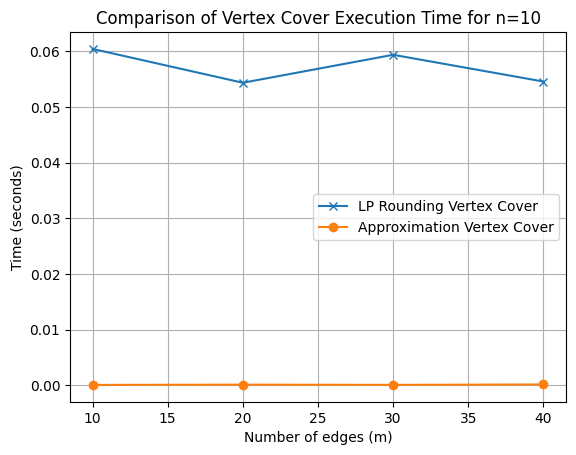

In [15]:
# Plot execution time of lp rounding vs greedy approximation verrtex cover algorithms for n=10
plt.plot(
    df_10['m'], 
    df_10['lp_vertex_cover_size_time_(in seconds)'],
    marker='x', 
    label='LP Rounding Vertex Cover' 
)

plt.plot(
    df_10['m'], 
    df_10['time (in seconds)'], 
    marker='o', 
    label='Approximation Vertex Cover'
)

# Label axes
plt.xlabel("Number of edges (m)")         # x-axis: number of edges in the graph
plt.ylabel("Time (seconds)")              # y-axis: execution time in seconds
plt.title("Comparison of Vertex Cover Execution Time for n=10")
plt.grid(True)
plt.legend()
plt.savefig("lp_greedy_comparison_n=10.png")
plt.show()

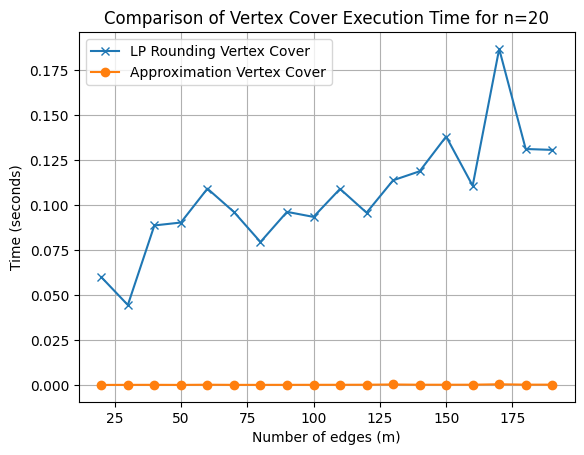

In [16]:
# Plot execution time of lp rounding vs greedy approximation verrtex cover algorithms for n=20
plt.plot(
    df_20['m'], 
    df_20['lp_vertex_cover_size_time_(in seconds)'],
    marker='x', 
    label='LP Rounding Vertex Cover' 
)

plt.plot(
    df_20['m'], 
    df_20['time_(in seconds)'], 
    marker='o', 
    label='Approximation Vertex Cover'
)

# Label axes
plt.xlabel("Number of edges (m)")         # x-axis: number of edges in the graph
plt.ylabel("Time (seconds)")              # y-axis: execution time in seconds
plt.title("Comparison of Vertex Cover Execution Time for n=20")
plt.grid(True)
plt.legend()
plt.savefig("lp_greedy_comparison_n=20.png")
plt.show()